## Step 1. 전역 설정

In [ ]:
import pandas as pd
# import gcsfs - 구글 클라우드용
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from scipy import stats
import warnings, os
from datetime import timedelta

warnings.filterwarnings('ignore')

import matplotlib, platform
if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')
matplotlib.rc('axes', unicode_minus=False)

print('라이브러리 로드 완료')
print(f'pandas {pd.__version__} / numpy {np.__version__}')

라이브러리 로드 완료
pandas 2.2.3 / numpy 2.2.4


In [8]:
GPR_FILE = 'data_gpr_daily_recent.csv' 
EVENT_DATES = {
    'hormuz_crisis'          : '2019-06-13',
    'soleimani_assassination': '2020-01-03',
    'russia_ukraine_war': '2022-02-24',
    'israel_hamas_war'           : '2023-10-07',
    'israel_iran'            : '2024-04-01',
    'us_israel_iran'         : '2026-02-28',
}

EVENT_LABELS = {
    'hormuz_crisis'          : '호르무즈 위기',
    'soleimani_assassination': '솔레이마니 암살',
    'russia_ukraine_war': '러-우 전쟁',
    'israel_hamas_war'           : '이스라엘-하마스',
    'israel_iran'            : '이스라엘-이란 충돌',
    'us_israel_iran'         : '이란 전쟁',
}

## 데이터 로드

In [10]:
CUSTOM_GPR_FILE = 'total_custom_gpr_final.csv'
result_df = pd.read_csv(CUSTOM_GPR_FILE)

display(result_df.head())

,date,N,mean_tone,sum_tone_x_polarity,sum_polarity,mean_pos,mean_neg,relative_N,coverage_scaled,F1_raw,...,F3_raw,F4_raw,F5_raw,F1_z,F2_z,F3_z,F4_z,F5_z,event_name,event_date
0,2019-01-01,364,-2.553468,-7398.410016,2656.407599,2.372178,4.925645,0.276824,0.244375,2.553468,...,0.624005,0.674947,2.785119,-1.267362,-1.375349,-0.986062,-1.333809,-3.295405,hormuz_crisis,2019-06-13
1,2019-01-02,420,-3.508872,-12417.685125,3146.357991,1.991228,5.500100,0.319412,0.277186,3.508872,...,0.972610,0.734196,3.396470,0.064986,0.138445,-0.773613,0.129983,-1.333957,hormuz_crisis,2019-06-13
2,2019-01-03,1160,-4.939393,-56527.656418,10488.934628,2.051396,6.990789,0.882185,0.632433,4.939393,...,3.123837,0.773131,4.131819,2.059905,2.018466,0.537399,1.091912,1.025325,hormuz_crisis,2019-06-13
3,2019-01-04,609,-2.934362,-14362.653018,4325.409318,2.084058,5.018420,0.463147,0.380590,2.934362,...,1.116788,0.706573,3.895910,-0.736190,-0.677582,-0.685748,-0.552459,0.268441,hormuz_crisis,2019-06-13
4,2019-01-05,394,-2.666511,-7815.197018,2697.765769,2.090305,4.756816,0.299639,0.262086,2.666511,...,0.698856,0.694718,3.651961,-1.109718,-1.229652,-0.940446,-0.845359,-0.514241,hormuz_crisis,2019-06-13


In [6]:
def load_official_gpr(path):
    if not os.path.exists(path):
        print(f'⚠️  {path} 없음 → 공식 GPR 없이 진행 (F1 기준 내부 상관분석)')
        return None
    try:
        gpr_raw = pd.read_csv(path)
    except Exception:
        try:
            gpr_raw = pd.read_stata(path)
        except Exception as e:
            print(f'GPR 파일 로드 실패: {e}')
            return None

    print('컬럼 목록:', list(gpr_raw.columns))
    print(gpr_raw.head(3))

    date_col = 'date' if 'date' in gpr_raw.columns else 'DAY'
    gpr_col = 'GPRD' if 'GPRD' in gpr_raw.columns else 'GPR'


    if date_col is None or gpr_col is None:
        print(f'컬럼 탐지 실패 — date_col={date_col}, gpr_col={gpr_col}')
        print("수동 지정: date_col='<날짜컬럼>', gpr_col='<GPR컬럼>'")
        return None

    print(f'\n날짜 컬럼: {date_col}, GPR 컬럼: {gpr_col}')
    gpr_raw[gpr_col] = pd.to_numeric(gpr_raw[gpr_col], errors='coerce')
    
    # 4. 날짜 변환 및 정리
    gpr_raw[date_col] = pd.to_datetime(gpr_raw[date_col].astype(str), errors='coerce')
    monthly = (
        gpr_raw[[date_col, gpr_col]].dropna()
        .rename(columns={date_col: 'month', gpr_col: 'GPR'})
        .set_index('month').sort_index()
    )
    daily_idx = pd.date_range(
        monthly.index.min(),
        monthly.index.max() + pd.offsets.MonthEnd(0),
        freq='D')
    daily = monthly.reindex(daily_idx).ffill()
    daily.index.name = 'date'
    daily['GPR_zscore'] = (
        (daily['GPR'] - daily['GPR'].mean()) / daily['GPR'].std())
    print(f'\n공식 GPR: {daily.index.min().date()} ~ {daily.index.max().date()}')
    return daily

gpr_daily = load_official_gpr(GPR_FILE)

컬럼 목록: ['DAY', 'N10D', 'GPRD', 'GPRD_ACT', 'GPRD_THREAT', 'date', 'GPRD_MA30', 'GPRD_MA7', 'event', 'var_name', 'var_label']
        DAY  N10D    GPRD GPRD_ACT  GPRD_THREAT        date  GPRD_MA30  \
0  19850101   216  230.04   275.20       153.03  1985-01-01     230.04   
1  19850102   315  115.68   146.77        87.44  1985-01-02     172.86   
2  19850103   374   97.43   158.94        29.46  1985-01-03     147.71   

   GPRD_MA7 event var_name                                         var_label  
0    230.04   NaN      DAY                                               DAY  
1    172.86   NaN     N10D  Number of articles (10 recent newspapers, 1985-)  
2    147.71   NaN     GPRD                  Daily GPR (Index: 1985:2019=100)  

날짜 컬럼: date, GPR 컬럼: GPRD

공식 GPR: 1985-01-01 ~ 2026-05-31


## EVENT_DATES에 설정된 이벤트 발생일을 기준으로 전후 30, 60,90일 상관관계 구하기

In [21]:
def merge_with_official_gpr(result_df, gpr_daily_df):
    if gpr_daily_df is None:
        return result_df
    gpr_ref = gpr_daily_df[['GPR','GPR_zscore']].copy()
    gpr_ref.index = pd.to_datetime(gpr_ref.index)
    result_df = result_df.copy()
    result_df['date'] = pd.to_datetime(result_df['date'])
    result_df = result_df.set_index('date').join(gpr_ref, how='left')
    return result_df.reset_index()


def correlation_analysis(result_df, event_name, gpr_available):
    # BUG-5 수정: ref_series 변수 선언 후 미사용 → 제거하고 로직 단순화
    rows           = []
    formula_cols_z = ['F1_z','F2_z','F3_z','F4_z','F5_z']

    if gpr_available and 'GPR_zscore' in result_df.columns:
        ref_label    = 'GPR 공식 (Z-score)'
        target_col   = 'GPR_zscore'
        compare_cols = formula_cols_z
    else:
        ref_label    = 'F1_z (기준)'
        target_col   = 'F1_z'
        compare_cols = formula_cols_z[1:]  # F2~F5 vs F1

    for f_col in compare_cols:
        pair = result_df[[f_col, target_col]].dropna()
        if len(pair) < 5:
            rows.append({'formula': f_col, 'n': len(pair),
                         'pearson_r': np.nan, 'pearson_p': np.nan,
                         'spearman_r': np.nan, 'spearman_p': np.nan})
            continue
        pr, pp = stats.pearsonr(pair[f_col], pair[target_col])
        sr, sp = stats.spearmanr(pair[f_col], pair[target_col])
        rows.append({'formula': f_col, 'n': len(pair),
                     'pearson_r': pr, 'pearson_p': pp,
                     'spearman_r': sr, 'spearman_p': sp})

    corr_df = pd.DataFrame(rows)
    corr_df['event']    = event_name
    corr_df['ref']      = ref_label
    corr_df['sig_5pct'] = corr_df['pearson_p'].apply(
        lambda p: '✅' if (pd.notna(p) and p < 0.05) else '—')
    return corr_df

### 30일 기준

In [22]:
gpr_results = {label: group for label, group in result_df.groupby('event_name')}

gpr_available  = gpr_daily is not None
merged_results = {}
for event, result in gpr_results.items():
    merged_results[event] = merge_with_official_gpr(result, gpr_daily)
all_corr = []
print(f'▶ 상관관계 분석 (전후 30일 제한, {"공식 GPR 기준" if gpr_available else "F1 기준"})\n')

for event, result in merged_results.items():
    # 1. 해당 이벤트의 기준 날짜 가져오기
    base_date_str = EVENT_DATES.get(event)
    
    if base_date_str:
        base_date = pd.to_datetime(base_date_str)
        # 2. 전후 30일 범위 설정
        start_date = base_date - timedelta(days=30)
        end_date = base_date + timedelta(days=30)
        
        # 3. 데이터 필터링 (결합된 데이터의 'date' 컬럼 기준)
        # merge_with_official_gpr 결과물은 'date'가 컬럼으로 리셋되어 있습니다.
        filtered_result = result[(result['date'] >= start_date) & (result['date'] <= end_date)].copy()
    else:
        # EVENT_DATES에 없는 이벤트인 경우 전체 기간 유지 혹은 스킵
        filtered_result = result.copy()

    # 4. 필터링된 데이터로 상관관계 분석 수행
    corr_df = correlation_analysis(filtered_result, event, gpr_available)
    all_corr.append(corr_df)
    
    # 출력 부분
    event_label = EVENT_LABELS.get(event, event)
    print(f'  [{event_label}] 기준일: {base_date_str if base_date_str else "N/A"}')
    print(f'  (분석 기간: {filtered_result["date"].min().date()} ~ {filtered_result["date"].max().date()}, n={len(filtered_result)})')
    print(corr_df[['formula','n','pearson_r','pearson_p',
                    'spearman_r','spearman_p','sig_5pct']].to_string(index=False))
    print()

corr_summary = pd.concat(all_corr, ignore_index=True) if all_corr else pd.DataFrame()

▶ 상관관계 분석 (전후 30일 제한, 공식 GPR 기준)

  [호르무즈 위기] 기준일: 2019-06-13
  (분석 기간: 2019-05-14 ~ 2019-07-13, n=61)
formula  n  pearson_r  pearson_p  spearman_r  spearman_p sig_5pct
   F1_z 61   0.294712   0.021132    0.290270    0.023251        ✅
   F2_z 61   0.267392   0.037225    0.279905    0.028905        ✅
   F3_z 61   0.515404   0.000021    0.546695    0.000005        ✅
   F4_z 61   0.319418   0.012099    0.274141    0.032520        ✅
   F5_z 61   0.239857   0.062622    0.256478    0.046018        —

  [이스라엘-하마스] 기준일: 2023-10-07
  (분석 기간: 2023-09-07 ~ 2023-11-06, n=61)
formula  n  pearson_r    pearson_p  spearman_r   spearman_p sig_5pct
   F1_z 61   0.483093 8.032527e-05    0.525013 1.399925e-05        ✅
   F2_z 61   0.428184 5.764840e-04    0.467319 1.464594e-04        ✅
   F3_z 61   0.716871 8.147975e-11    0.700687 3.244561e-10        ✅
   F4_z 61   0.485342 7.355503e-05    0.499630 4.143293e-05        ✅
   F5_z 61   0.599573 3.292336e-07    0.607192 2.124265e-07        ✅

  [이스라엘-이란 충돌] 

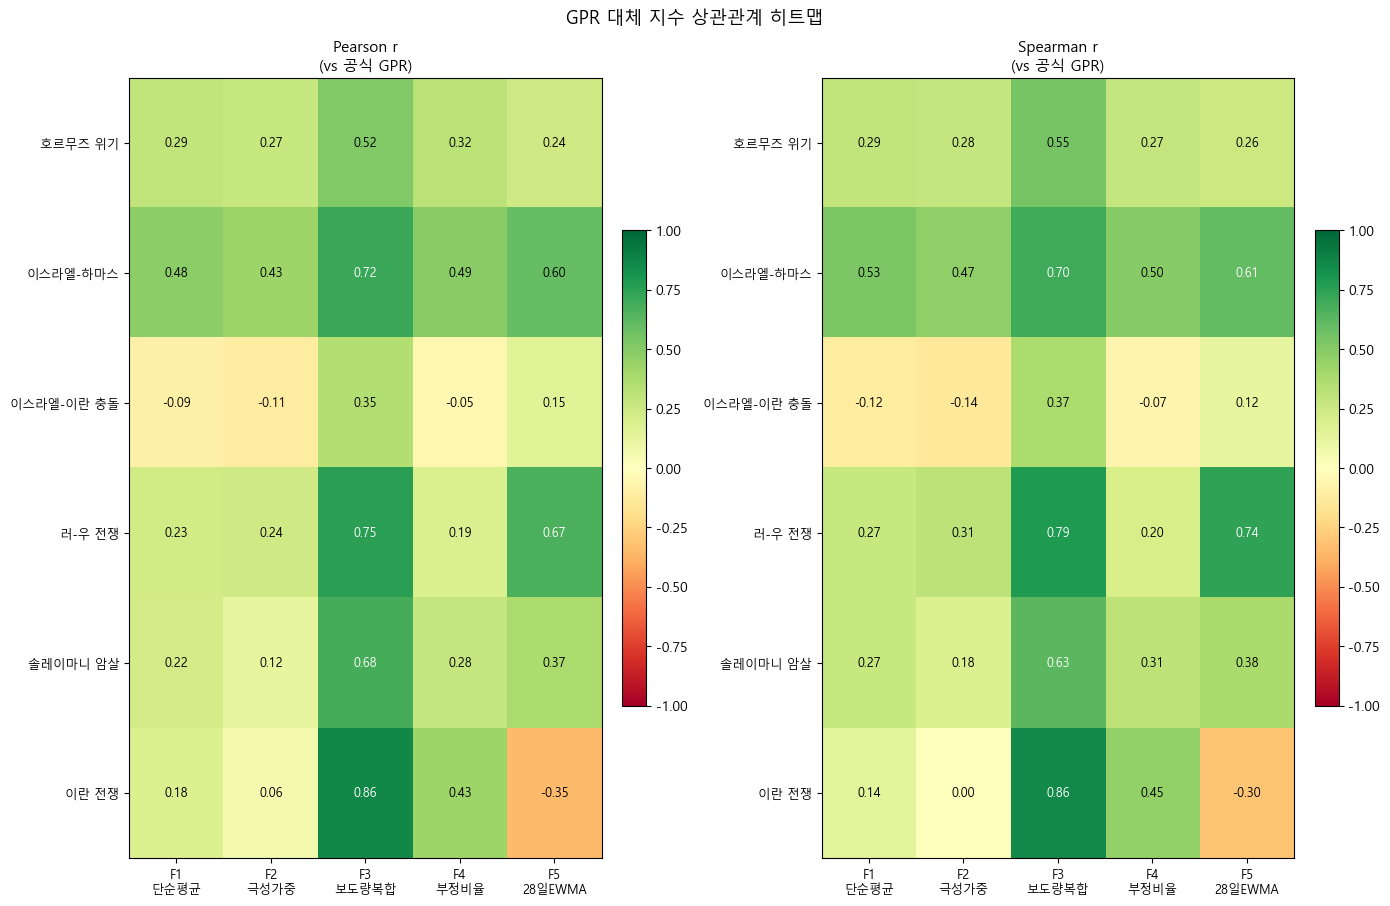

저장: 03_correlation_heatmap(30).png


In [23]:
# ── 상관계수 히트맵 ───────────────────────────────────────
formula_cols_z = ['F1_z','F2_z','F3_z','F4_z','F5_z']
formula_labels = ['F1\n단순평균','F2\n극성가중','F3\n보도량복합',
                  'F4\n부정비율','F5\n28일EWMA']

if corr_summary.empty:
    print('상관관계 데이터 없음 — 히트맵 생략')
else:
    fig, axes = plt.subplots(1, 2,
                             figsize=(14, max(4, len(gpr_results) * 1.2 + 2)))
    for ax_i, (metric, metric_label) in enumerate(
            [('pearson_r','Pearson r'), ('spearman_r','Spearman r')]):
        ax = axes[ax_i]
        pivot = corr_summary.pivot_table(
            index='event', columns='formula', values=metric, aggfunc='first')
        pivot = pivot.reindex(
            columns=[c for c in formula_cols_z if c in pivot.columns])
        im = ax.imshow(pivot.values.astype(float), cmap='RdYlGn',
                       vmin=-1, vmax=1, aspect='auto')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(pivot.shape[1]))
        ax.set_xticklabels(
            [formula_labels[formula_cols_z.index(c)]
             for c in pivot.columns], fontsize=9)
        ax.set_yticks(range(pivot.shape[0]))
        ax.set_yticklabels(
            [EVENT_LABELS.get(e, e) for e in pivot.index], fontsize=9)
        ax.set_title(
            f'{metric_label}\n({"vs 공식 GPR" if gpr_available else "vs F1"})',
            fontsize=11)
        for row in range(pivot.shape[0]):
            for col in range(pivot.shape[1]):
                val = pivot.values[row, col]
                if pd.notna(val):
                    ax.text(col, row, f'{val:.2f}', ha='center', va='center',
                            fontsize=9,
                            color='white' if abs(val) > 0.6 else 'black')
    plt.suptitle('GPR 대체 지수 상관관계 히트맵', fontsize=13)
    plt.tight_layout()
    plt.savefig('03_correlation_heatmap(30).png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: 03_correlation_heatmap(30).png')

## 60일 기준

In [24]:
gpr_results = {label: group for label, group in result_df.groupby('event_name')}

gpr_available  = gpr_daily is not None
merged_results = {}
for event, result in gpr_results.items():
    merged_results[event] = merge_with_official_gpr(result, gpr_daily)
all_corr = []
print(f'▶ 상관관계 분석 (전후 60일 제한, {"공식 GPR 기준" if gpr_available else "F1 기준"})\n')

for event, result in merged_results.items():
    # 1. 해당 이벤트의 기준 날짜 가져오기
    base_date_str = EVENT_DATES.get(event)
    
    if base_date_str:
        base_date = pd.to_datetime(base_date_str)
        # 2. 전후 60일 범위 설정
        start_date = base_date - timedelta(days=60)
        end_date = base_date + timedelta(days=60)
        
        # 3. 데이터 필터링 (결합된 데이터의 'date' 컬럼 기준)
        # merge_with_official_gpr 결과물은 'date'가 컬럼으로 리셋되어 있습니다.
        filtered_result = result[(result['date'] >= start_date) & (result['date'] <= end_date)].copy()
    else:
        # EVENT_DATES에 없는 이벤트인 경우 전체 기간 유지 혹은 스킵
        filtered_result = result.copy()

    # 4. 필터링된 데이터로 상관관계 분석 수행
    corr_df = correlation_analysis(filtered_result, event, gpr_available)
    all_corr.append(corr_df)
    
    # 출력 부분
    event_label = EVENT_LABELS.get(event, event)
    print(f'  [{event_label}] 기준일: {base_date_str if base_date_str else "N/A"}')
    print(f'  (분석 기간: {filtered_result["date"].min().date()} ~ {filtered_result["date"].max().date()}, n={len(filtered_result)})')
    print(corr_df[['formula','n','pearson_r','pearson_p',
                    'spearman_r','spearman_p','sig_5pct']].to_string(index=False))
    print()

corr_summary = pd.concat(all_corr, ignore_index=True) if all_corr else pd.DataFrame()

▶ 상관관계 분석 (전후 60일 제한, 공식 GPR 기준)

  [호르무즈 위기] 기준일: 2019-06-13
  (분석 기간: 2019-04-14 ~ 2019-08-12, n=121)
formula   n  pearson_r  pearson_p  spearman_r  spearman_p sig_5pct
   F1_z 121   0.085192   0.352852    0.095732    0.296242        —
   F2_z 121   0.076283   0.405625    0.104112    0.255775        —
   F3_z 121   0.366498   0.000036    0.392745    0.000008        ✅
   F4_z 121   0.096711   0.291307    0.096356    0.293095        —
   F5_z 121   0.175935   0.053572    0.186696    0.040326        —

  [이스라엘-하마스] 기준일: 2023-10-07
  (분석 기간: 2023-08-08 ~ 2023-12-06, n=121)
formula   n  pearson_r    pearson_p  spearman_r   spearman_p sig_5pct
   F1_z 121   0.393265 8.113714e-06    0.438823 4.785329e-07        ✅
   F2_z 121   0.305752 6.486584e-04    0.338321 1.473708e-04        ✅
   F3_z 121   0.684270 5.068273e-18    0.683695 5.538630e-18        ✅
   F4_z 121   0.380478 1.670845e-05    0.420654 1.555368e-06        ✅
   F5_z 121   0.441141 4.096627e-07    0.502845 4.163300e-09        ✅

 

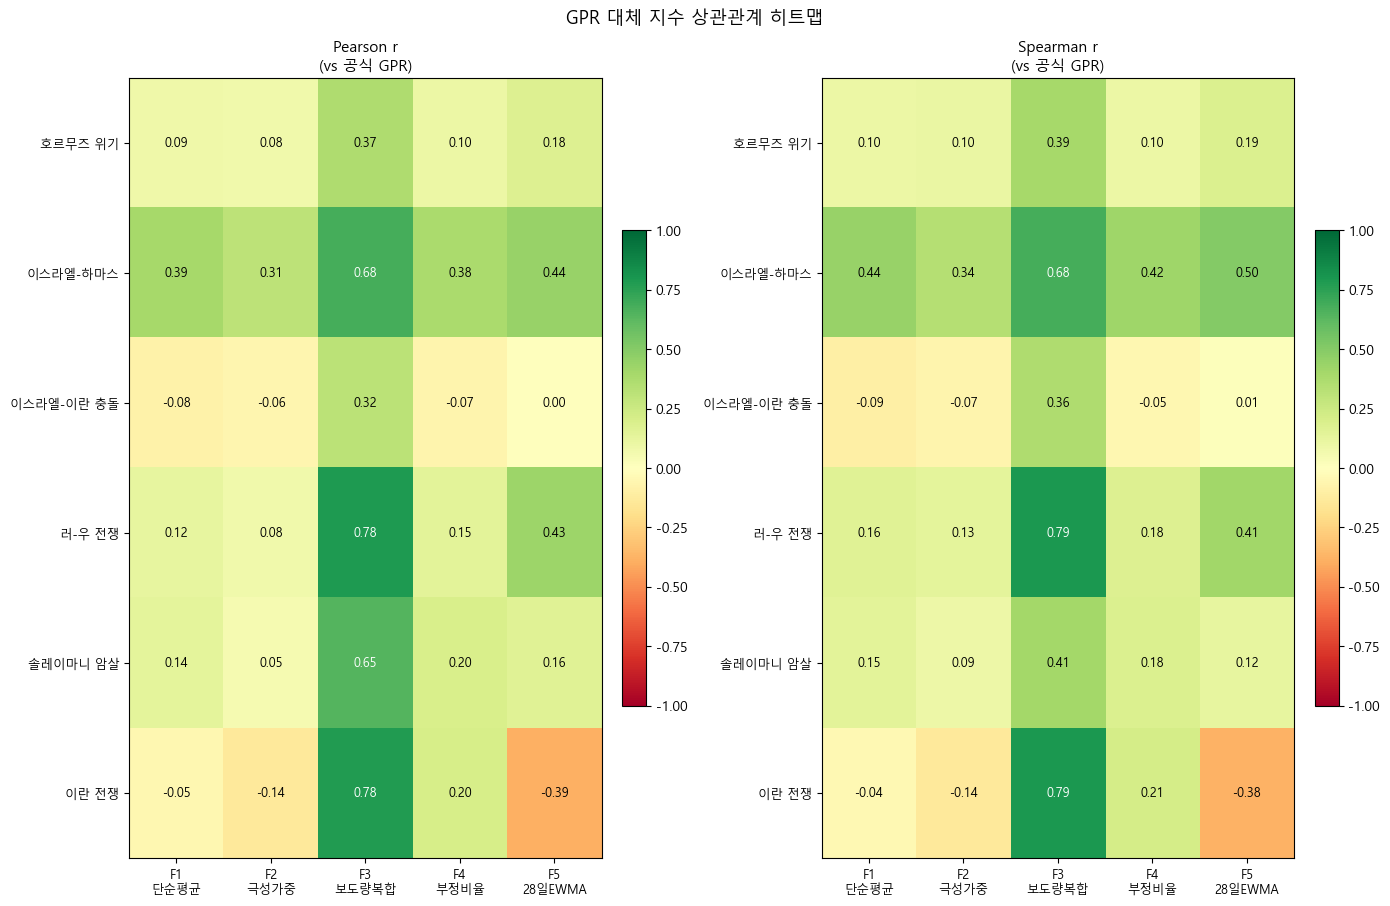

저장: 03_correlation_heatmap(60).png


In [25]:
# ── 상관계수 히트맵 ───────────────────────────────────────
formula_cols_z = ['F1_z','F2_z','F3_z','F4_z','F5_z']
formula_labels = ['F1\n단순평균','F2\n극성가중','F3\n보도량복합',
                  'F4\n부정비율','F5\n28일EWMA']

if corr_summary.empty:
    print('상관관계 데이터 없음 — 히트맵 생략')
else:
    fig, axes = plt.subplots(1, 2,
                             figsize=(14, max(4, len(gpr_results) * 1.2 + 2)))
    for ax_i, (metric, metric_label) in enumerate(
            [('pearson_r','Pearson r'), ('spearman_r','Spearman r')]):
        ax = axes[ax_i]
        pivot = corr_summary.pivot_table(
            index='event', columns='formula', values=metric, aggfunc='first')
        pivot = pivot.reindex(
            columns=[c for c in formula_cols_z if c in pivot.columns])
        im = ax.imshow(pivot.values.astype(float), cmap='RdYlGn',
                       vmin=-1, vmax=1, aspect='auto')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(pivot.shape[1]))
        ax.set_xticklabels(
            [formula_labels[formula_cols_z.index(c)]
             for c in pivot.columns], fontsize=9)
        ax.set_yticks(range(pivot.shape[0]))
        ax.set_yticklabels(
            [EVENT_LABELS.get(e, e) for e in pivot.index], fontsize=9)
        ax.set_title(
            f'{metric_label}\n({"vs 공식 GPR" if gpr_available else "vs F1"})',
            fontsize=11)
        for row in range(pivot.shape[0]):
            for col in range(pivot.shape[1]):
                val = pivot.values[row, col]
                if pd.notna(val):
                    ax.text(col, row, f'{val:.2f}', ha='center', va='center',
                            fontsize=9,
                            color='white' if abs(val) > 0.6 else 'black')
    plt.suptitle('GPR 대체 지수 상관관계 히트맵', fontsize=13)
    plt.tight_layout()
    plt.savefig('03_correlation_heatmap(60).png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: 03_correlation_heatmap(60).png')

### 90일 기준

In [26]:
gpr_results = {label: group for label, group in result_df.groupby('event_name')}

gpr_available  = gpr_daily is not None
merged_results = {}
for event, result in gpr_results.items():
    merged_results[event] = merge_with_official_gpr(result, gpr_daily)
all_corr = []
print(f'▶ 상관관계 분석 (전후 90일 제한, {"공식 GPR 기준" if gpr_available else "F1 기준"})\n')

for event, result in merged_results.items():
    # 1. 해당 이벤트의 기준 날짜 가져오기
    base_date_str = EVENT_DATES.get(event)
    
    if base_date_str:
        base_date = pd.to_datetime(base_date_str)
        # 2. 전후 90일 범위 설정
        start_date = base_date - timedelta(days=90)
        end_date = base_date + timedelta(days=90)
        
        # 3. 데이터 필터링 (결합된 데이터의 'date' 컬럼 기준)
        # merge_with_official_gpr 결과물은 'date'가 컬럼으로 리셋되어 있습니다.
        filtered_result = result[(result['date'] >= start_date) & (result['date'] <= end_date)].copy()
    else:
        # EVENT_DATES에 없는 이벤트인 경우 전체 기간 유지 혹은 스킵
        filtered_result = result.copy()

    # 4. 필터링된 데이터로 상관관계 분석 수행
    corr_df = correlation_analysis(filtered_result, event, gpr_available)
    all_corr.append(corr_df)
    
    # 출력 부분
    event_label = EVENT_LABELS.get(event, event)
    print(f'  [{event_label}] 기준일: {base_date_str if base_date_str else "N/A"}')
    print(f'  (분석 기간: {filtered_result["date"].min().date()} ~ {filtered_result["date"].max().date()}, n={len(filtered_result)})')
    print(corr_df[['formula','n','pearson_r','pearson_p',
                    'spearman_r','spearman_p','sig_5pct']].to_string(index=False))
    print()

corr_summary = pd.concat(all_corr, ignore_index=True) if all_corr else pd.DataFrame()

▶ 상관관계 분석 (전후 90일 제한, 공식 GPR 기준)

  [호르무즈 위기] 기준일: 2019-06-13
  (분석 기간: 2019-03-15 ~ 2019-09-11, n=181)
formula   n  pearson_r    pearson_p  spearman_r   spearman_p sig_5pct
   F1_z 181   0.069456 3.528491e-01    0.073919 3.226922e-01        —
   F2_z 181   0.050800 4.970413e-01    0.067078 3.696148e-01        —
   F3_z 181   0.395717 3.514215e-08    0.401089 2.200578e-08        ✅
   F4_z 181   0.077327 3.008236e-01    0.065574 3.804654e-01        —
   F5_z 181   0.208879 4.773878e-03    0.197748 7.621466e-03        ✅

  [이스라엘-하마스] 기준일: 2023-10-07
  (분석 기간: 2023-07-09 ~ 2024-01-02, n=178)
formula   n  pearson_r    pearson_p  spearman_r   spearman_p sig_5pct
   F1_z 178   0.288533 9.391833e-05    0.300090 4.707613e-05        ✅
   F2_z 178   0.206968 5.572639e-03    0.217957 3.470747e-03        ✅
   F3_z 178   0.636888 1.225365e-21    0.599681 9.185616e-19        ✅
   F4_z 178   0.285549 1.117201e-04    0.291518 7.879651e-05        ✅
   F5_z 178   0.377032 2.131116e-07    0.426364 2.9558

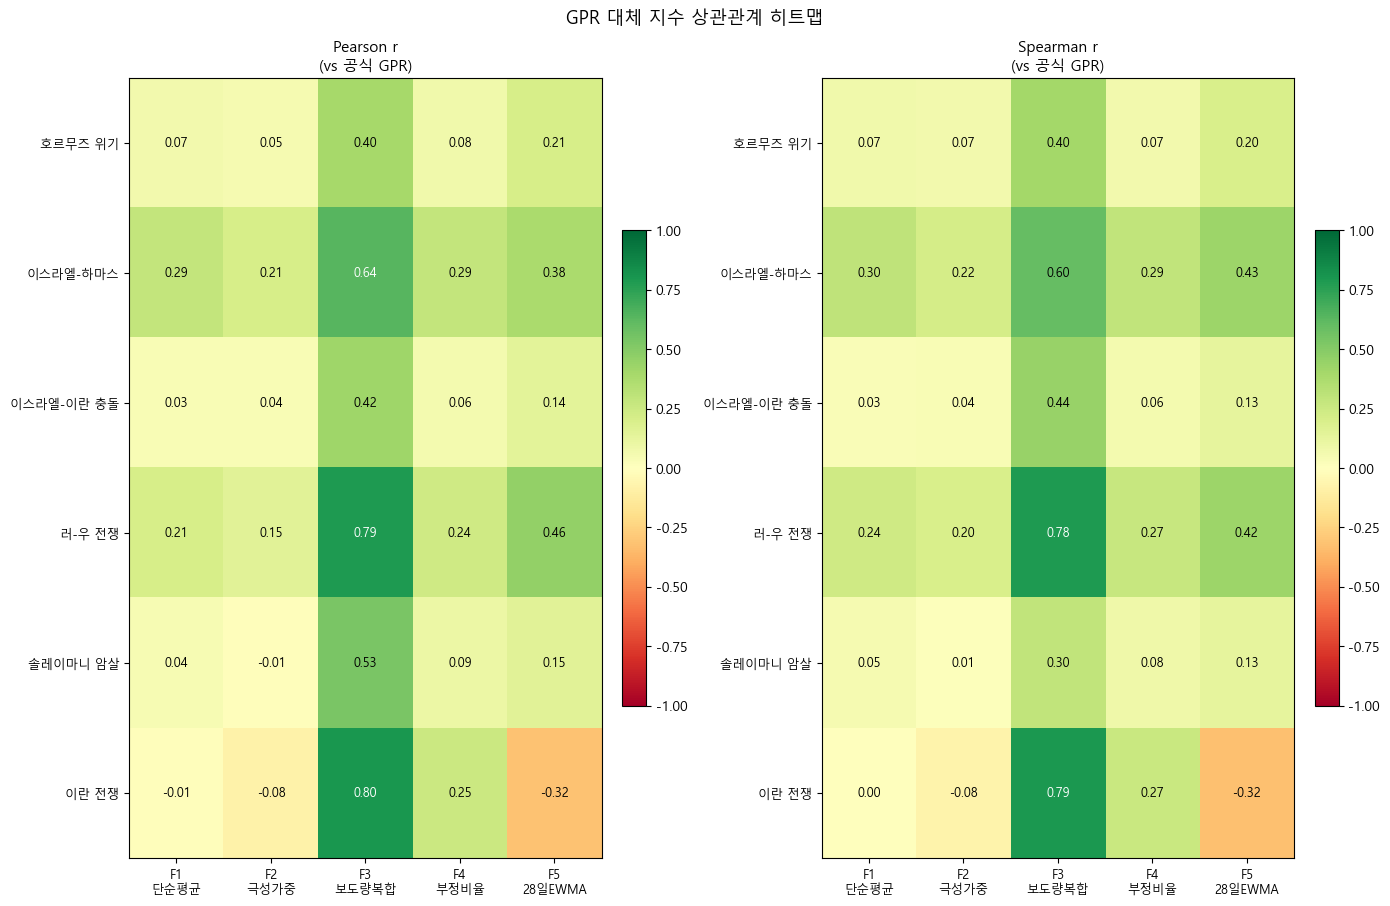

저장: 03_correlation_heatmap(90).png


In [27]:
# ── 상관계수 히트맵 ───────────────────────────────────────
formula_cols_z = ['F1_z','F2_z','F3_z','F4_z','F5_z']
formula_labels = ['F1\n단순평균','F2\n극성가중','F3\n보도량복합',
                  'F4\n부정비율','F5\n28일EWMA']

if corr_summary.empty:
    print('상관관계 데이터 없음 — 히트맵 생략')
else:
    fig, axes = plt.subplots(1, 2,
                             figsize=(14, max(4, len(gpr_results) * 1.2 + 2)))
    for ax_i, (metric, metric_label) in enumerate(
            [('pearson_r','Pearson r'), ('spearman_r','Spearman r')]):
        ax = axes[ax_i]
        pivot = corr_summary.pivot_table(
            index='event', columns='formula', values=metric, aggfunc='first')
        pivot = pivot.reindex(
            columns=[c for c in formula_cols_z if c in pivot.columns])
        im = ax.imshow(pivot.values.astype(float), cmap='RdYlGn',
                       vmin=-1, vmax=1, aspect='auto')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(pivot.shape[1]))
        ax.set_xticklabels(
            [formula_labels[formula_cols_z.index(c)]
             for c in pivot.columns], fontsize=9)
        ax.set_yticks(range(pivot.shape[0]))
        ax.set_yticklabels(
            [EVENT_LABELS.get(e, e) for e in pivot.index], fontsize=9)
        ax.set_title(
            f'{metric_label}\n({"vs 공식 GPR" if gpr_available else "vs F1"})',
            fontsize=11)
        for row in range(pivot.shape[0]):
            for col in range(pivot.shape[1]):
                val = pivot.values[row, col]
                if pd.notna(val):
                    ax.text(col, row, f'{val:.2f}', ha='center', va='center',
                            fontsize=9,
                            color='white' if abs(val) > 0.6 else 'black')
    plt.suptitle('GPR 대체 지수 상관관계 히트맵', fontsize=13)
    plt.tight_layout()
    plt.savefig('03_correlation_heatmap(90).png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: 03_correlation_heatmap(90).png')